In [1]:
import pandas as pd
from datasets import load_dataset

/home4/s6019595/.llmvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_aime = pd.read_csv("hf://datasets/di-zhang-fdu/AIME_1983_2024/AIME_Dataset_1983_2024.csv")
print(f"AIME: {len(df_aime)} problems")
print(f"Columns: {list(df_aime.columns)}")
df_aime.head()


AIME: 933 problems
Columns: ['ID', 'Year', 'Problem Number', 'Question', 'Answer', 'Part']


,ID,Year,Problem Number,Question,Answer,Part
0,1983-1,1983,1,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60,NaN
1,1983-2,1983,2,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15,NaN
2,1983-3,1983,3,What is the product of the real roots of the e...,20,NaN
3,1983-4,1983,4,A machine-shop cutting tool has the shape of a...,26,NaN
4,1983-5,1983,5,Suppose that the sum of the squares of two com...,4,NaN


In [3]:
df_math = pd.read_parquet("hf://datasets/qwedsacf/competition_math/data/train-00000-of-00001-7320a6f3aba8ebd2.parquet")
print(f"MATH: {len(df_math)} problems")
print(f"Columns: {list(df_math.columns)}")
df_math.head()


MATH: 12500 problems
Columns: ['problem', 'level', 'type', 'solution']


,problem,level,type,solution
0,"Let \[f(x) = \left\{\n\begin{array}{cl} ax+3, ...",Level 5,Algebra,"For the piecewise function to be continuous, t..."
1,A rectangular band formation is a formation wi...,Level 5,Algebra,Let $x$ be the number of band members in each ...
2,What is the degree of the polynomial $(4 +5x^3...,Level 3,Algebra,This polynomial is not written in standard for...
3,Evaluate $\left\lceil3\left(6-\frac12\right)\r...,Level 3,Algebra,"Firstly, $3\left(6-\frac12\right)=18-1-\frac12..."
4,Sam is hired for a 20-day period. On days that...,Level 3,Algebra,Call $x$ the number of days Sam works and $y$ ...


In [4]:
df_math500 = pd.read_json("hf://datasets/HuggingFaceH4/MATH-500/test.jsonl", lines=True)
print(f"MATH-500: {len(df_math500)} problems")
print(f"Columns: {list(df_math500.columns)}")
df_math500.head()


MATH-500: 500 problems
Columns: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']


,problem,solution,answer,subject,level,unique_id
0,"Convert the point $(0,3)$ in rectangular coord...",We have that $r = \sqrt{0^2 + 3^2} = 3.$ Also...,"\left( 3, \frac{\pi}{2} \right)",Precalculus,2,test/precalculus/807.json
1,Define\n\[p = \sum_{k = 1}^\infty \frac{1}{k^2...,We count the number of times $\frac{1}{n^3}$ a...,p - q,Intermediate Algebra,5,test/intermediate_algebra/1994.json
2,"If $f(x) = \frac{3x-2}{x-2}$, what is the valu...",$f(-2)+f(-1)+f(0)=\frac{3(-2)-2}{-2-2}+\frac{3...,\frac{14}{3},Algebra,3,test/algebra/2584.json
3,How many positive whole-number divisors does 1...,First prime factorize $196=2^2\cdot7^2$. The ...,9,Number Theory,3,test/number_theory/572.json
4,The results of a cross-country team's training...,Evelyn covered more distance in less time than...,\text{Evelyn},Algebra,2,test/algebra/1349.json


In [5]:
math_questions = set(df_math['problem'])
math500_questions = set(df_math500['problem'])
common_questions = math_questions.intersection(math500_questions)
print(f"Number of common questions between MATH and MATH-500: {len(common_questions)}")

Number of common questions between MATH and MATH-500: 500


In [6]:
dataset_gsm8k = load_dataset("openai/gsm8k", "main", split="test")
df_gsm8k = pd.DataFrame(dataset_gsm8k)
print(f"GSM8K: {len(df_gsm8k)} problems")
print(f"Columns: {list(df_gsm8k.columns)}")
df_gsm8k.head()


GSM8K: 1319 problems
Columns: ['question', 'answer']


,question,answer
0,Janet’s ducks lay 16 eggs per day. She eats th...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...
1,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...
2,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...
3,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...
4,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t..."


In [7]:
dataset_olympiad = load_dataset("lmms-lab/OlympiadBench", split="test_en") # option test_en, test_cn
df_olympiad = pd.DataFrame(dataset_olympiad)


print(f"Olympiad: {len(df_olympiad)} problems")
print(f"Columns: {list(df_olympiad.columns)}")
df_olympiad.head()


Olympiad: 2126 problems
Columns: ['question_id', 'subfield', 'context', 'question', 'images', 'final_answer', 'is_multiple_answer', 'unit', 'answer_type', 'error', 'source']


,question_id,subfield,context,question,images,final_answer,is_multiple_answer,unit,answer_type,error,source
0,1735,Geometry,None,"Three circular arcs $\gamma_{1}, \gamma_{2}$, ...",[<PIL.JpegImagePlugin.JpegImageFile image mode...,None,True,None,None,None,TP_MM_maths_en_COMP
1,1975,Combinatorics,None,Construct a tetromino by attaching two $2 \tim...,[<PIL.JpegImagePlugin.JpegImageFile image mode...,None,True,None,None,None,TP_MM_maths_en_COMP
2,2039,Combinatorics,None,An anti-Pascal pyramid is a finite set of numb...,[<PIL.JpegImagePlugin.JpegImageFile image mode...,None,True,None,None,None,TP_MM_maths_en_COMP
3,2184,Geometry,None,"Let $A B C D$ be a cyclic quadrilateral, and l...",[<PIL.JpegImagePlugin.JpegImageFile image mode...,None,True,None,None,None,TP_MM_maths_en_COMP
4,2227,Geometry,None,Let $H$ be the orthocenter and $G$ be the cent...,[<PIL.JpegImagePlugin.JpegImageFile image mode...,None,True,None,None,None,TP_MM_maths_en_COMP


In [8]:
# AMC uses the same AIME dataset source
df_amc = df_aime.copy()
df_amc = df_amc.rename(columns={"Question": "problem", "Answer": "solution"})
print(f"AMC: {len(df_amc)} problems")
print(f"Normalized columns: {list(df_amc.columns)}")
df_amc[["problem", "solution"]].head()


AMC: 933 problems
Normalized columns: ['ID', 'Year', 'Problem Number', 'problem', 'solution', 'Part']


,problem,solution
0,"Let $x$ , $y$ and $z$ all exceed $1$ and let $...",60
1,"Let $f(x)=|x-p|+|x-15|+|x-p-15|$ , where $0 < ...",15
2,What is the product of the real roots of the e...,20
3,A machine-shop cutting tool has the shape of a...,26
4,Suppose that the sum of the squares of two com...,4


In [9]:
summary = pd.DataFrame({
    "Dataset": ["AIME", "MATH", "MATH-500", "GSM8K", "Olympiad"],
    "Size": [len(df_aime), len(df_math), len(df_math500), len(df_gsm8k), len(df_olympiad)],
})
summary

,Dataset,Size
0,AIME,933
1,MATH,12500
2,MATH-500,500
3,GSM8K,1319
4,Olympiad,2126


In [10]:
print("AIME",list(df_aime.columns))
print("MATH",list(df_math.columns))
print("MATH 500",list(df_math500.columns))
print("GSM8K",list(df_gsm8k.columns))
print("Olympiad",list(df_olympiad.columns))

AIME ['ID', 'Year', 'Problem Number', 'Question', 'Answer', 'Part']
MATH ['problem', 'level', 'type', 'solution']
MATH 500 ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']
GSM8K ['question', 'answer']
Olympiad ['question_id', 'subfield', 'context', 'question', 'images', 'final_answer', 'is_multiple_answer', 'unit', 'answer_type', 'error', 'source']


In [11]:
#remove math500 duplicates from math
math_questions = set(df_math['problem'])
math500_questions = set(df_math500['problem'])  
common_questions = math_questions.intersection(math500_questions)
df_math = df_math[~df_math['problem'].isin(common_questions)]
print(f"After removing {len(common_questions)} duplicates, MATH now has {len(df_math)} problems.")

After removing 500 duplicates, MATH now has 12000 problems.


In [12]:
df_all =pd.DataFrame(columns=["dataset", "problem", "solution", "level"])

#TRAINING DATASETS
df_aime_temp = df_aime.rename(columns={"Question": "problem", "Answer": "solution"})
df_aime_temp["dataset"] = "AIME"
df_aime_temp["level"] = None
df_all = pd.concat([df_all, df_aime_temp[["dataset", "problem", "solution", "level"]]])

df_math_temp = df_math.rename(columns={"problem": "problem", "solution": "solution"})
df_math_temp["dataset"] = "MATH"
df_math_temp["level"] = df_math["level"]
df_all = pd.concat([df_all, df_math_temp[["dataset", "problem", "solution", "level"]]])

#EVALUATION DATASETS

df_math500_temp = df_math500.rename(columns={"problem": "problem", "solution": "solution"})
df_math500_temp["dataset"] = "MATH-500"
df_math500_temp["level"] = df_math500["level"]
df_all = pd.concat([df_all, df_math500_temp[["dataset", "problem", "solution", "level"]]])

df_gsm8k_temp = df_gsm8k.rename(columns={"question": "problem", "answer": "solution"})
df_gsm8k_temp["dataset"] = "GSM8K"
df_gsm8k_temp["level"] = None
df_all = pd.concat([df_all, df_gsm8k_temp[["dataset", "problem", "solution", "level"]]])

df_olympiad_temp = df_olympiad.rename(columns={"question": "problem", "final_answer": "solution"})
df_olympiad_temp["dataset"] = "Olympiad"
df_olympiad_temp["level"] = None
df_all = pd.concat([df_all, df_olympiad_temp[["dataset", "problem", "solution", "level"]]]) 


In [13]:
df_all = df_all.reset_index(drop=True)
df_all["id"] = df_all.index
df_all = df_all[["id", "dataset", "problem", "solution", "level"]]
print(f"Final combined dataframe: {len(df_all)} problems")
df_all.tail(5)

Final combined dataframe: 16878 problems


,id,dataset,problem,solution,level
16873,16873,Olympiad,2. A uniform magnetic field $\boldsymbol{B}$ ...,[$\omega_{0}=\gamma B_{0}$],None
16874,16874,Olympiad,"2. For $\boldsymbol{B}=B_{0} \boldsymbol{k}$,...",[$\Delta =\gamma B_{0}-\omega$],None
16875,16875,Olympiad,4. Instead of applying the field $\boldsymbol...,[$\mathbf{B}_{\mathrm{eff}}=\left(B_{0}-\frac{...,None
16876,16876,Olympiad,"1. In the rotating frame $S^{\prime}$, show t...",[$\Omega=\gamma b$],None
16877,16877,Olympiad,3. Under the application of magnetic field de...,[$P_{\downarrow}=\sin ^{2} \frac{\Omega t}{2}$...,None


In [14]:
def normalize_solution(x):
    if isinstance(x, list):
        # join list elements into a single string
        return "\n".join(map(str, x))
    elif x is None:
        return None
    else:
        return str(x)

def normalize_level(x):
    """Remove "Level " prefix from level strings.
       Cast float levels to int
       set nan levels to None
    """
    if isinstance(x, str) and x.startswith("Level "):
        x = x.replace("Level ", "")
    if isinstance(x, float) and x.is_integer():
        return str(int(x))
    elif pd.isna(x):
        return None
    else:
        return str(x)

def deduplicate_dataframe(df):
    """Deduplicate dataframe based on 'problem' column."""
    before_dedup = len(df)
    df_dedup = df.drop_duplicates(subset=["problem"])
    after_dedup = len(df_dedup)
    print(f"Removed {before_dedup - after_dedup} duplicate problems. New size: {after_dedup}")
    return df_dedup

In [15]:
df_all["solution"] = df_all["solution"].apply(normalize_solution)
df_all["level"] = df_all["level"].apply(normalize_level)
df_all = deduplicate_dataframe(df_all)
#reset id column to be sequential
df_all = df_all.reset_index(drop=True)
df_all["id"] = df_all.index


Removed 8 duplicate problems. New size: 16870


In [16]:
df_all.nunique()

id          16870
dataset         5
problem     16870
solution    15435
level           6
dtype: int64

In [17]:
#show unique levels
df_all["level"].unique()

array([None, '5', '3', '4', '1', '2', '?'], dtype=object)

In [18]:
#check if all ids are sequential
expected_ids = set(range(len(df_all)))
actual_ids = set(df_all['id'])


if expected_ids == actual_ids:
    print("All IDs are sequential and accounted for.")
else:
    missing_ids = expected_ids - actual_ids
    print(f"Missing IDs: {missing_ids}")


All IDs are sequential and accounted for.


In [19]:
df_all["dataset"].unique()

array(['AIME', 'MATH', 'MATH-500', 'GSM8K', 'Olympiad'], dtype=object)

In [20]:
df_train = df_all[df_all["dataset"].isin(["AIME", "MATH"])]
df_eval = df_all[df_all["dataset"].isin(["MATH-500", "GSM8K", "Olympiad"])]

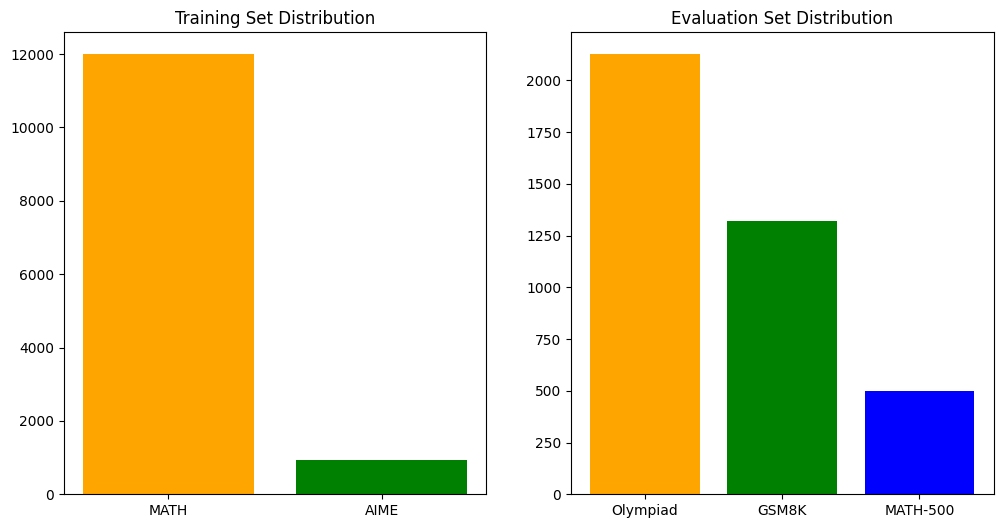

In [29]:
#Plot percentage of each dataset in train and eval sets
import matplotlib.pyplot as plt

fig,axs = plt.subplots(1, 2, figsize=(12, 6))
train_counts = df_train["dataset"].value_counts()
axs[0].bar(train_counts.index, train_counts.values, color=['orange', 'green', 'blue'])
axs[0].set_title("Training Set Distribution")       
eval_counts = df_eval["dataset"].value_counts()
axs[1].bar(eval_counts.index, eval_counts.values, color=['orange', 'green', 'blue'])
axs[1].set_title("Evaluation Set Distribution")
plt.show()

In [26]:
DATA_PATH_RAW = "/home4/s6019595/llm-think-too-much/data/raw/"
df_train.to_parquet(f"{DATA_PATH_RAW}train_data.parquet")

df_eval.to_parquet(f"{DATA_PATH_RAW}eval_data.parquet")